# 3. Modeling

This notebook trains baseline machine learning models to predict Remaining Useful Life (RUL) for turbofan engines.

The modeling stage includes:

- loading the feature-engineered dataset
- splitting the data by engine to avoid leakage
- training baseline regression models
- evaluating model performance using standard regression metrics

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression

from xgboost import XGBRegressor

## 3.1 Load Feature-Engineered Data

This notebook uses the processed dataset created in the feature engineering stage.

The dataset includes:

- selected raw sensor values
- rolling statistics
- trend-based features
- the target variable `RUL`

In [3]:
df_model = pd.read_csv("/Users/junghanlee/Downloads/1. Python Code/2. NASA Turbofan Jet Engine/1. Data/processed/train_feature_engineered.csv")
df_model.head()

,engine_id,cycle,RUL,sensor_2,sensor_3,sensor_4,sensor_7,sensor_8,sensor_9,sensor_11,...,sensor_7_lag1,sensor_8_lag1,sensor_9_lag1,sensor_11_lag1,sensor_12_lag1,sensor_13_lag1,sensor_14_lag1,sensor_15_lag1,sensor_20_lag1,sensor_21_lag1
0,1,5,125.0,642.37,1582.85,1406.22,554.00,2388.06,9055.15,47.28,...,554.45,2388.11,9049.48,47.13,522.86,2388.08,8133.83,8.3682,38.88,23.3739
1,1,6,125.0,642.10,1584.47,1398.37,554.67,2388.02,9049.68,47.16,...,554.00,2388.06,9055.15,47.28,522.19,2388.04,8133.80,8.4294,38.90,23.4044
2,1,7,125.0,642.48,1592.32,1397.77,554.34,2388.02,9059.13,47.36,...,554.67,2388.02,9049.68,47.16,521.68,2388.03,8132.85,8.4108,38.98,23.3669
3,1,8,125.0,642.56,1582.96,1400.97,553.85,2388.00,9040.80,47.24,...,554.34,2388.02,9059.13,47.36,522.32,2388.03,8132.32,8.3974,39.10,23.3774
4,1,9,125.0,642.12,1590.98,1394.80,553.69,2388.05,9046.46,47.29,...,553.85,2388.00,9040.80,47.24,522.47,2388.03,8131.07,8.4076,38.97,23.3106


## 3.2 Initial Data Check

Before modeling, the dataset is checked to confirm its structure and feature availability.

In [4]:
print("Shape:", df_model.shape)
print("Number of columns:", len(df_model.columns))
df_model.columns.tolist()

Shape: (20231, 68)
Number of columns: 68


['engine_id',
 'cycle',
 'RUL',
 'sensor_2',
 'sensor_3',
 'sensor_4',
 'sensor_7',
 'sensor_8',
 'sensor_9',
 'sensor_11',
 'sensor_12',
 'sensor_13',
 'sensor_14',
 'sensor_15',
 'sensor_20',
 'sensor_21',
 'sensor_2_roll_mean',
 'sensor_2_roll_std',
 'sensor_3_roll_mean',
 'sensor_3_roll_std',
 'sensor_4_roll_mean',
 'sensor_4_roll_std',
 'sensor_7_roll_mean',
 'sensor_7_roll_std',
 'sensor_8_roll_mean',
 'sensor_8_roll_std',
 'sensor_9_roll_mean',
 'sensor_9_roll_std',
 'sensor_11_roll_mean',
 'sensor_11_roll_std',
 'sensor_12_roll_mean',
 'sensor_12_roll_std',
 'sensor_13_roll_mean',
 'sensor_13_roll_std',
 'sensor_14_roll_mean',
 'sensor_14_roll_std',
 'sensor_15_roll_mean',
 'sensor_15_roll_std',
 'sensor_20_roll_mean',
 'sensor_20_roll_std',
 'sensor_21_roll_mean',
 'sensor_21_roll_std',
 'sensor_2_diff',
 'sensor_3_diff',
 'sensor_4_diff',
 'sensor_7_diff',
 'sensor_8_diff',
 'sensor_9_diff',
 'sensor_11_diff',
 'sensor_12_diff',
 'sensor_13_diff',
 'sensor_14_diff',
 'sensor_

## 3.3 Define Features and Target

The target variable is `RUL`.

The variables `engine_id` and `cycle` are excluded from the feature set:

- `engine_id` is only an identifier
- `cycle` is not used to avoid overly relying on time index information

In [5]:
target = "RUL"
drop_cols = ["engine_id", "cycle", "RUL"]

X = df_model.drop(columns=drop_cols)
y = df_model[target]
groups = df_model["engine_id"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (20231, 65)
Target shape: (20231,)


## 3.4 Train/Test Split by Engine

Because multiple rows belong to the same engine over time, a random row-based split would cause leakage.

To avoid this, the data is split by `engine_id` so that cycles from the same engine do not appear in both training and test sets.

This provides a more realistic evaluation of how the model would perform on unseen engines.

In [6]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]
y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

train_engines = df_model.iloc[train_idx]["engine_id"].nunique()
test_engines = df_model.iloc[test_idx]["engine_id"].nunique()

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Train engines:", train_engines)
print("Test engines:", test_engines)

X_train shape: (16241, 65)
X_test shape: (3990, 65)
Train engines: 80
Test engines: 20


In [7]:
train_engine_ids = set(df_model.iloc[train_idx]["engine_id"])
test_engine_ids = set(df_model.iloc[test_idx]["engine_id"])

print("Overlap in engine IDs:", len(train_engine_ids.intersection(test_engine_ids)))

Overlap in engine IDs: 0


## 3.5 Baseline Model: Linear Regression

A simple Linear Regression model is trained first as a baseline.

This provides a reference point for comparing more advanced nonlinear models.

In [8]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [9]:
def evaluate_model(model_name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    return pd.DataFrame({
        "Model": [model_name],
        "RMSE": [rmse],
        "MAE": [mae],
        "R2": [r2]
    })

In [10]:
results_lr = evaluate_model("Linear Regression", y_test, y_pred_lr)
results_lr

,Model,RMSE,MAE,R2
0,Linear Regression,19.903894,16.014843,0.772901


## 3.7 Random Forest Regressor

A Random Forest model is used as the primary baseline model.

This model can capture nonlinear relationships and interactions between sensor features, which are common in predictive maintenance problems.

In [11]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=12,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [12]:
results_rf = evaluate_model("Random Forest", y_test, y_pred_rf)
results_rf

,Model,RMSE,MAE,R2
0,Random Forest,16.454689,11.565914,0.84479


## 3.8 Gradient Boosting Regressor

Gradient Boosting is also tested as another nonlinear baseline model.

Boosting methods often perform well when feature interactions are important.

In [13]:
gbr = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

gbr.fit(X_train, y_train)

y_pred_gbr = gbr.predict(X_test)

In [14]:
results_gbr = evaluate_model("Gradient Boosting", y_test, y_pred_gbr)
results_gbr

,Model,RMSE,MAE,R2
0,Gradient Boosting,16.386232,11.734599,0.846079


## 3.9 XGBoost Regressor

XGBoost is tested as an advanced gradient boosting model for Remaining Useful Life prediction.

It is often effective for structured tabular datasets because it can capture nonlinear relationships and feature interactions while controlling overfitting.

In [47]:
xgb = XGBRegressor(
    n_estimators=1000,
    max_depth=5,
    learning_rate=0.01,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    reg_alpha=0.1,
    reg_lambda=1,
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

In [48]:
results_xgb = evaluate_model("XGBoost", y_test, y_pred_xgb)
results_xgb

,Model,RMSE,MAE,R2
0,XGBoost,16.268001,11.546807,0.848292


## 3.10 Model Comparison

The baseline models are compared using the same evaluation metrics on the held-out test engines.

In [49]:
results = pd.concat([results_lr, results_rf, results_gbr, results_xgb], ignore_index=True)
results.sort_values("RMSE")

,Model,RMSE,MAE,R2
3,XGBoost,16.268001,11.546807,0.848292
2,Gradient Boosting,16.386232,11.734599,0.846079
1,Random Forest,16.454689,11.565914,0.844790
0,Linear Regression,19.903894,16.014843,0.772901


## 3.11 Actual vs Predicted RUL

The relationship between actual and predicted RUL values is visualized to assess model fit.

A stronger alignment along the diagonal indicates better predictive performance.

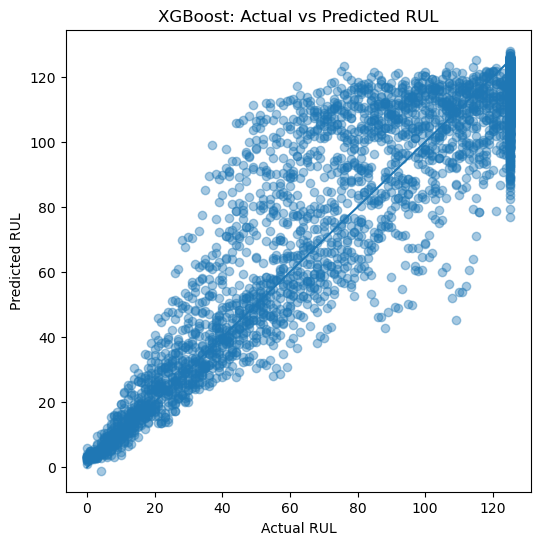

In [51]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_xgb, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.title("XGBoost: Actual vs Predicted RUL")
plt.show()

## 3.12 Residual Analysis

Residual plots help identify systematic prediction errors.

If the residuals are randomly distributed around zero, the model is less likely to have strong bias.

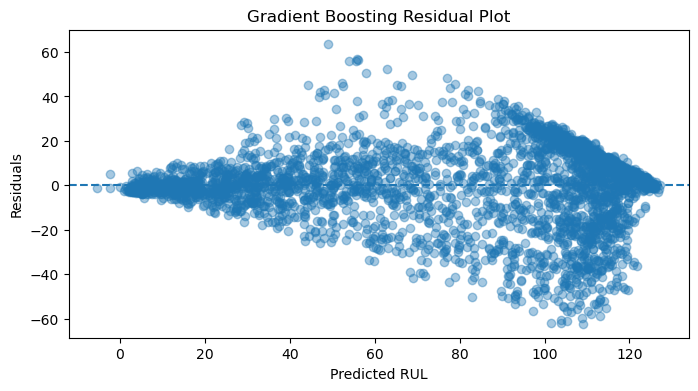

In [52]:
residuals_xgb = y_test - y_pred_xgb

plt.figure(figsize=(8,4))
plt.scatter(y_pred_gbr, residuals_xgb, alpha=0.4)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted RUL")
plt.ylabel("Residuals")
plt.title("Gradient Boosting Residual Plot")
plt.show()


## 3.13 Feature Importance

Feature importance from the Random Forest model is used to identify which engineered variables contribute most to prediction performance.

In [53]:
feature_importance = pd.Series(rf.feature_importances_, index=X_train.columns)
feature_importance = feature_importance.sort_values(ascending=False)

feature_importance.head(15)

sensor_4_roll_mean     0.621161
sensor_11_roll_mean    0.117066
sensor_9_roll_mean     0.092893
sensor_20_roll_mean    0.015585
sensor_14_roll_mean    0.015353
sensor_7_roll_mean     0.011386
sensor_15_roll_mean    0.011111
sensor_21_roll_mean    0.010331
sensor_2_roll_mean     0.007026
sensor_9               0.006945
sensor_12_roll_mean    0.005585
sensor_3_roll_mean     0.005480
sensor_13_roll_mean    0.004603
sensor_14_roll_std     0.003922
sensor_8_roll_mean     0.003691
dtype: float64

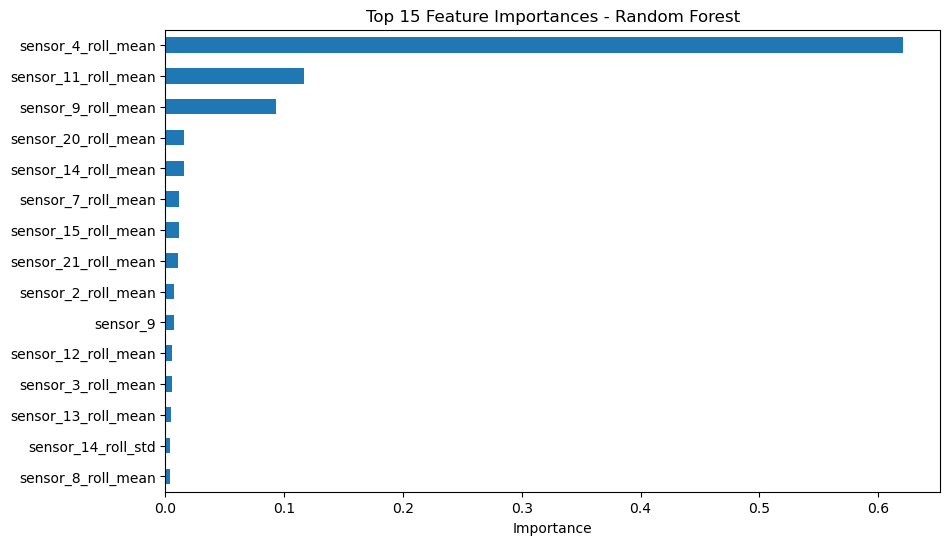

In [54]:
plt.figure(figsize=(10,6))
feature_importance.head(15).sort_values().plot(kind="barh")
plt.title("Top 15 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.show()

## 3.14 Save Modeling Results

Evaluation outputs and selected artifacts can be saved for later use in the final project report or README.

In [55]:
results.to_csv("/Users/junghanlee/Downloads/1. Python Code/2. NASA Turbofan Jet Engine/1. Data/processed/model_results.csv", index=False)
feature_importance.to_csv("/Users/junghanlee/Downloads/1. Python Code/2. NASA Turbofan Jet Engine/1. Data/processed/feature_importance.csv")

## 3.15 Summary

In this notebook, multiple baseline regression models were trained to predict Remaining Useful Life (RUL).

Key points:

- The dataset was split by engine to avoid leakage across time-series observations.
- Linear Regression was used as a simple baseline.
- Random Forest and Gradient Boosting were used as nonlinear models.
- Model performance was evaluated using RMSE, MAE, and R².
- Feature importance analysis identified the most influential engineered variables.

These results provide a strong baseline for further model tuning and advanced approaches.